# Imports

In [1]:
import pandas as pd
import sys
import psycopg2
import os
from pathlib import Path

# move up from analytics/analysis/ to repo root
PROJECT_ROOT = Path.cwd().resolve().parents[1]
while PROJECT_ROOT.name != "procurement_agent" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

from dotenv import load_dotenv 
from analytics.scoring import SupplierScorer, load_contract

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent


# DB Connection

In [2]:
load_dotenv() # Load environment variables from .env file

True

In [3]:
conn = psycopg2.connect(
    dbname=os.getenv('PGDATABASE'),
    user=os.getenv('PGUSER'),
    password=os.getenv('PGPASSWORD'),
    host=os.getenv('PGHOST'),
    port=os.getenv('PGPORT')
)

print("Database connection established successfully.")

Database connection established successfully.


# Load SQL View

In [4]:
query = """
SELECT * FROM vw_supplier_complete_profile
"""

df = pd.read_sql(query, conn)

df.shape

/var/folders/7r/bkznjk192kggm19g_v70_z240000gn/T/ipykernel_64216/692280052.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(91, 18)

# Initialize Scorer and Scoring Contract

In [5]:
contract = load_contract(str(PROJECT_ROOT / "analytics" / "metric_contract.yaml"))
scorer = SupplierScorer(contract)

# Run Scoring

In [6]:
result = scorer.score(df,
                      Q=6000,
                      lambda_risk=0.5,
                      top_k=25)

ranked = result.ranked
dropped = result.dropped_rows

# Inspecting Score Distributions

In [7]:
ranked[[
    "EffectiveUnitPrice",
    "RiskPenalty",
    "RiskAdjustedCost"
]].describe()

,EffectiveUnitPrice,RiskPenalty,RiskAdjustedCost
count,25.000000,25.000000,25.000000
mean,0.266148,29.727044,0.460498
std,0.217801,8.667618,0.167528
min,0.096426,12.474134,0.185741
25%,0.107700,25.950105,0.354337
50%,0.151970,29.430868,0.500000
75%,0.497954,31.771857,0.615037
max,0.800686,53.800998,0.664619


**EffectiveUnitPrice Interpretation**
This is normalized so:
- ~0.09 = cheapest supplier in product group
- ~0.80 = most expensive supplier in product grouping

**RiskPenalty Interpretation**
- Raw Risk Penalty (lower score better)

**RiskAdjustedCost Interpretation**
- Cost after incorporating Risk Penalty.
- LandedUnitPrice + lambda * RiskPenalty
Normalized score. Good spread (lower score better)

# Validate Decision Tier Calibration

Ensuring the new decision tier calibration logic in `calibration.py` is being called from inside `scoring.py`, and that the final returned output includes the named `DecisionTier` field from the metric contract.

In [8]:
# Confirming new calibrated decision tier fields exist in final returned results
print("Columns in ranked output:", ranked.columns)

Columns in ranked output: Index(['SupplierID', 'CountryCode', 'Product', 'LeadTimeMean',
       'LeadTimeStdDev', 'LeadTimeVariance', 'DisruptionProbability',
       'ComplianceEligibility', 'LogisticsReliability', 'ProbabilityOfDefect',
       'BaselinePrice', 'PriceVolatility', 'BulkDiscount',
       'UnitsNeededForBulk', 'TariffRatePct', 'HTS8_TariffCode',
       'TariffDescription', 'LeadTimeCoefficientOfVariation', 'DisruptionRisk',
       'LogisticsRisk', 'QualityRisk', 'CostInstabilityRisk', 'LeadTimeRisk',
       'EffectiveUnitPrice', 'LandedUnitCost', 'RiskPenalty',
       'RiskAdjustedCost', 'DecisionTier', 'TopAdjustedCostDrivers',
       'TopRiskDrivers'],
      dtype='str')


In [9]:
assert "DecisionTier" in ranked.columns, "DecisionTier column is missing from ranked results"
print("DecisionTier column successfully returned in ranked results")

DecisionTier column successfully returned in ranked results


# Inspecting Decision Tier Distribution

In [10]:
ranked["DecisionTier"].value_counts(dropna=False)

DecisionTier
Preferred     17
Acceptable     8
Name: count, dtype: int64

# Inspecting Decision Tiers by Product

In [11]:
ranked[[
    "SupplierID",
    "Product",
    "RiskAdjustedCost",
    "DecisionTier"
]].sort_values(["Product", "RiskAdjustedCost"]) # top 25 suppliers

,SupplierID,Product,RiskAdjustedCost,DecisionTier
0,SUP_CAN_11,integrated_circuit_components,0.185741,Preferred
1,SUP_CAN_9,integrated_circuit_components,0.186045,Preferred
8,SUP_HKG_39,integrated_circuit_components,0.361839,Preferred
19,SUP_HKG_33,integrated_circuit_components,0.635749,Preferred
24,SUP_HKG_34,integrated_circuit_components,0.664619,Preferred
12,SUP_MYS_64,microprocessors,0.500000,Preferred
2,SUP_SGP_77,power_devices,0.200082,Preferred
7,SUP_SGP_70,power_devices,0.359267,Preferred
10,SUP_DEU_20,power_devices,0.467526,Preferred
15,SUP_DEU_22,power_devices,0.530470,Preferred


# Ensuring Decision Tier Calibration Behaving Sensibly

In [12]:
ranked.groupby(["Product", "DecisionTier"]).size().reset_index(name="count") # top 25

,Product,DecisionTier,count
0,integrated_circuit_components,Preferred,5
1,microprocessors,Preferred,1
2,power_devices,Acceptable,2
3,power_devices,Preferred,5
4,transistors,Acceptable,6
5,transistors,Preferred,6


In [40]:
result = scorer.score(
    df,
    Q=6000,
    lambda_risk=0.5,
    top_k = len(df)
)

ranked = result.ranked

In [41]:
ranked.groupby(["Product", "DecisionTier"]).size().reset_index(name="count")

,Product,DecisionTier,count
0,integrated_circuit_components,Acceptable,7
1,integrated_circuit_components,Avoid,8
2,integrated_circuit_components,Preferred,6
3,microprocessors,Acceptable,1
4,microprocessors,Avoid,2
5,microprocessors,Preferred,1
6,power_devices,Acceptable,6
7,power_devices,Avoid,6
8,power_devices,Preferred,5
9,transistors,Acceptable,7


# Ranking Inspection

In [42]:
# inspecting top suppliers

ranked[
    ["SupplierID", "CountryCode", "Product", "EffectiveUnitPrice", "RiskPenalty", "RiskAdjustedCost"]
].sort_values("RiskAdjustedCost").head(10)

,SupplierID,CountryCode,Product,EffectiveUnitPrice,RiskPenalty,RiskAdjustedCost
0,SUP_CAN_11,CAN,integrated_circuit_components,0.151970,30.809375,0.185741
1,SUP_CAN_9,CAN,integrated_circuit_components,0.159260,23.858238,0.186045
2,SUP_SGP_77,SGP,power_devices,0.481646,26.485064,0.200082
3,SUP_CAN_10,CAN,transistors,0.106179,25.151669,0.206584
4,SUP_HKG_38,HKG,transistors,0.104347,26.986416,0.217087
5,SUP_HKG_35,HKG,transistors,0.105323,30.534479,0.347906
6,SUP_HKG_40,HKG,transistors,0.110838,26.707136,0.354337
7,SUP_SGP_70,SGP,power_devices,0.497954,30.899356,0.359267
8,SUP_HKG_39,HKG,integrated_circuit_components,0.157130,34.441400,0.361839
9,SUP_SGP_72,SGP,transistors,0.107700,31.138305,0.419834


In [43]:
for product, group in ranked.groupby("Product"):
    print(f"\nTop suppliers for {product.upper()}")

    display(
        group[
            ["SupplierID",
             "CountryCode",
             "EffectiveUnitPrice",
             "LandedUnitCost",
             "RiskPenalty",
             "RiskAdjustedCost"]
        ].sort_values("RiskAdjustedCost").head(10)
    ) 


Top suppliers for INTEGRATED_CIRCUIT_COMPONENTS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
0,SUP_CAN_11,CAN,0.15197,0.157289,30.809375,0.185741
1,SUP_CAN_9,CAN,0.15926,0.164834,23.858238,0.186045
8,SUP_HKG_39,HKG,0.15713,0.162630,34.441400,0.361839
19,SUP_HKG_33,HKG,0.17174,0.177751,30.976021,0.635749
24,SUP_HKG_34,HKG,0.17434,0.180442,29.430868,0.664619
25,SUP_USA_90,USA,0.17907,0.179070,31.070924,0.668146
27,SUP_HKG_37,HKG,0.17722,0.183423,28.246848,0.707891
31,SUP_SGP_76,SGP,0.18358,0.190005,24.832381,0.786331
34,SUP_SGP_69,SGP,0.18018,0.186486,29.209569,0.799023
36,SUP_NLD_65,NLD,0.17268,0.178724,39.023374,0.830406



Top suppliers for MICROPROCESSORS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
12,SUP_MYS_64,MYS,0.800686,0.800686,53.800998,0.500000
33,SUP_NLD_67,NLD,1.184451,1.184451,27.676172,0.791949
38,SUP_DEU_24,DEU,1.252093,1.252093,23.851481,0.860699
57,SUP_JPN_48,JPN,1.325490,1.325490,31.542301,1.129874



Top suppliers for POWER_DEVICES


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
2,SUP_SGP_77,SGP,0.481646,0.481646,26.485064,0.200082
7,SUP_SGP_70,SGP,0.497954,0.497954,30.899356,0.359267
10,SUP_DEU_20,DEU,0.553399,0.553399,12.474134,0.467526
15,SUP_DEU_22,DEU,0.552563,0.552563,17.764823,0.530470
16,SUP_DEU_25,DEU,0.547729,0.547729,21.377432,0.552258
17,SUP_FIN_27,FIN,0.519750,0.519750,35.248558,0.572230
22,SUP_DEU_21,DEU,0.573841,0.573841,17.108551,0.664450
28,SUP_NLD_68,NLD,0.551410,0.551410,32.009816,0.737470
30,SUP_DEU_19,DEU,0.586024,0.586024,17.826135,0.757649
32,SUP_GBR_31,GBR,0.559107,0.559107,31.827557,0.786767



Top suppliers for TRANSISTORS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
3,SUP_CAN_10,CAN,0.106179,0.106179,25.151669,0.206584
4,SUP_HKG_38,HKG,0.104347,0.104347,26.986416,0.217087
5,SUP_HKG_35,HKG,0.105323,0.105323,30.534479,0.347906
6,SUP_HKG_40,HKG,0.110838,0.110838,26.707136,0.354337
9,SUP_SGP_72,SGP,0.107700,0.107700,31.138305,0.419834
11,SUP_MYS_63,MYS,0.096426,0.096426,40.857606,0.477390
13,SUP_AUS_4,AUS,0.110517,0.110517,31.771857,0.502560
14,SUP_MYS_62,MYS,0.099354,0.099354,40.677220,0.525143
18,SUP_AUS_5,AUS,0.118869,0.118869,29.323411,0.615037
20,SUP_MYS_58,MYS,0.103568,0.103568,41.767060,0.647943


# Dropped Rows Audit

In [17]:
# ensuring contract enforcement is working
dropped['drop_reason'].value_counts()

drop_reason
gate:compliance_gate    29
Name: count, dtype: int64

# Risk vs Price Visualization

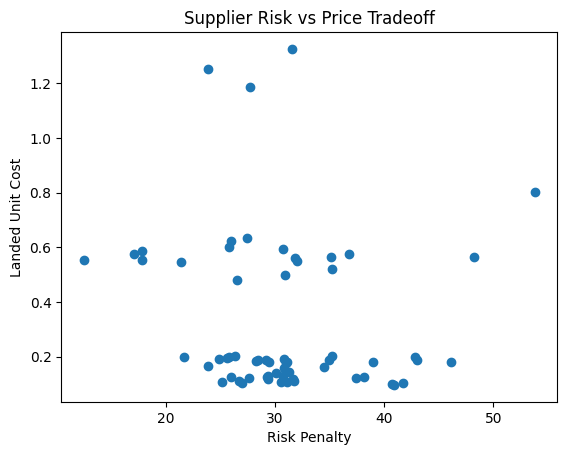

In [18]:
import matplotlib.pyplot as plt

plt.scatter(
    ranked['RiskPenalty'],
    ranked['LandedUnitCost'],
)

plt.xlabel('Risk Penalty')
plt.ylabel('Landed Unit Cost')
plt.title('Supplier Risk vs Price Tradeoff')
plt.show()

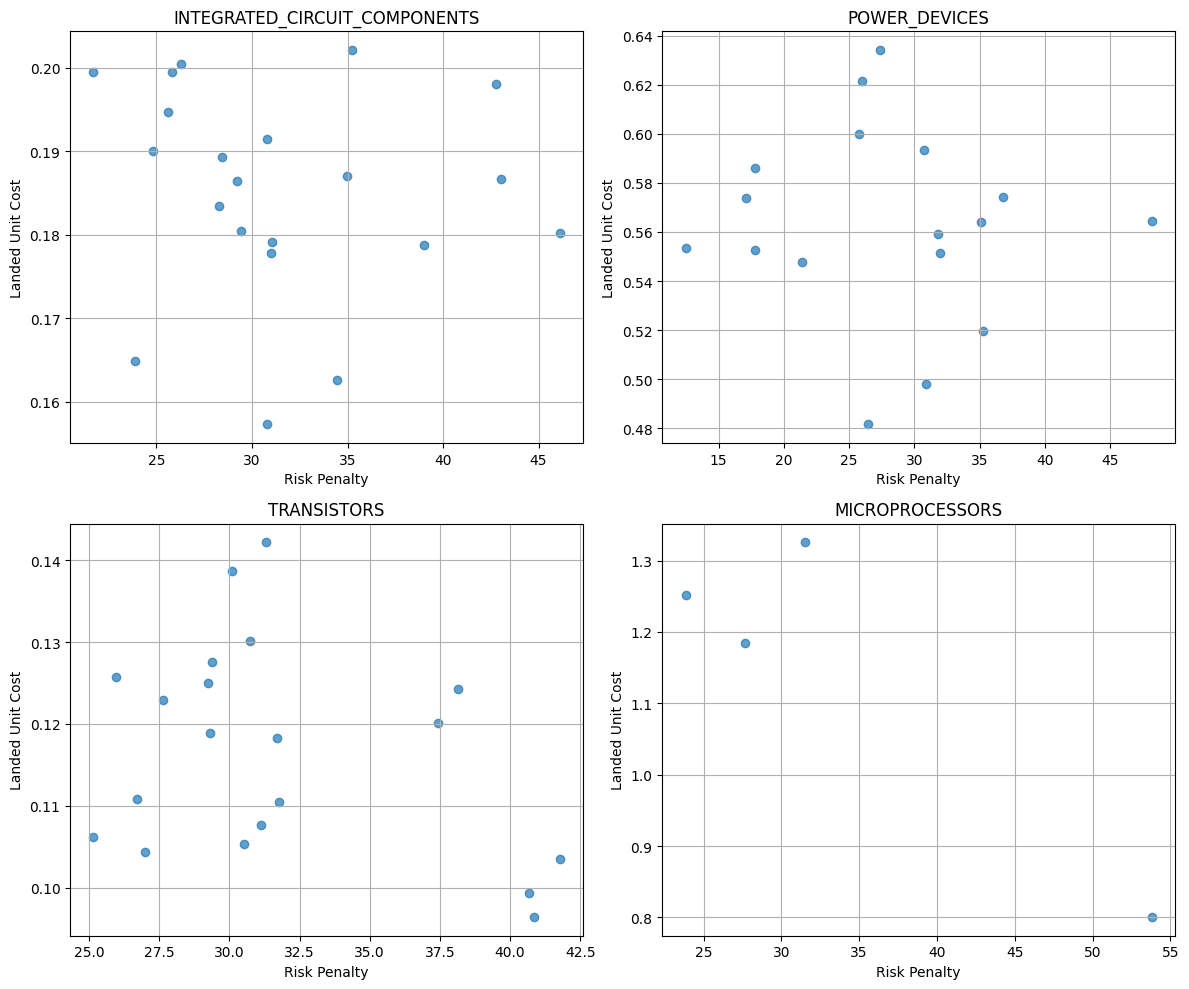

In [19]:
products = ranked['Product'].unique()

fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes = axes.flatten()

for i, product in enumerate(products):
    subset = ranked[ranked["Product"]== product]

    axes[i].scatter(
        subset['RiskPenalty'],
        subset['LandedUnitCost'],
        alpha=0.7
    )

    axes[i].set_title(product.upper())
    axes[i].set_xlabel('Risk Penalty')
    axes[i].set_ylabel('Landed Unit Cost')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# other than transistors, the risk penalty vs landed cost tradeoff looks like what youd expect - as risk penalty increases, so does landed cost, but with some variance as some suppliers are able to offer better prices despite higher risk (or vice versa)